# ESG Risk Classification: S&P 500
**Predicting High-Risk Companies Using Logistic Regression — From Scratch**

This project classifies S&P 500 companies into ESG high-risk vs low-risk groups using a logistic regression model implemented from scratch, based on principles learned in class.

## Step 1. Load & Explore Data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv('/Users/jungyoon/Downloads/SP 500 ESG Risk Ratings.csv')
print(df.shape)
print(df['ESG Risk Level'].value_counts())
print('Missing values:', df['ESG Risk Level'].isnull().sum())
print(df.head())

(503, 15)
ESG Risk Level
Low           187
Medium        184
High           50
Negligible      6
Severe          3
Name: count, dtype: int64
Missing values: 73
  Symbol                      Name  \
0   ENPH      Enphase Energy, Inc.   
1    EMN  Eastman Chemical Company   
2    DPZ       Domino's Pizza Inc.   
3    DAY            Dayforce, Inc.   
4    DVA               Davita Inc.   

                                             Address             Sector  \
0  47281 Bayside Parkway\nFremont, CA 94538\nUnit...         Technology   
1  200 South Wilcox Drive\nKingsport, TN 37662\nU...    Basic Materials   
2  30 Frank Lloyd Wright Drive\nAnn Arbor, MI 481...  Consumer Cyclical   
3  3311 East Old Shakopee Road\nMinneapolis, MN 5...         Technology   
4  2000 16th Street\nDenver, CO 80202\nUnited States         Healthcare   

                  Industry Full Time Employees  \
0                    Solar               3,157   
1      Specialty Chemicals              14,000   
2         

## Step 2. Preprocessing

- High + Severe → High Risk (1)
- Low + Medium + Negligible → Low Risk (0)
- Drop rows with missing values

In [3]:
cols = ['Environment Risk Score', 'Governance Risk Score',
        'Social Risk Score', 'Controversy Score',
        'ESG Risk Level', 'Sector']

df_esg = df[cols].copy()
df_esg = df_esg.dropna()

# Binary label
df_esg['label'] = df_esg['ESG Risk Level'].apply(
    lambda x: 1 if x in ['High', 'Severe'] else 0
)

print(df_esg['label'].value_counts())
print(f'Total: {df_esg.shape[0]} companies')

label
0    350
1     53
Name: count, dtype: int64
Total: 403 companies


## Step 3. Statistical Analysis (t-test)

Before modeling, verify that all features show **statistically significant differences** between risk groups.

Null hypothesis H0: No difference in mean scores between High Risk and Low Risk groups.

t-test Results:
------------------------------------------------------------
Environment Risk Score: t=-14.87, p=0.0000 → Significant
Governance Risk Score: t=-2.53, p=0.0119 → Significant
Social Risk Score: t=-7.67, p=0.0000 → Significant
Controversy Score: t=-4.69, p=0.0000 → Significant


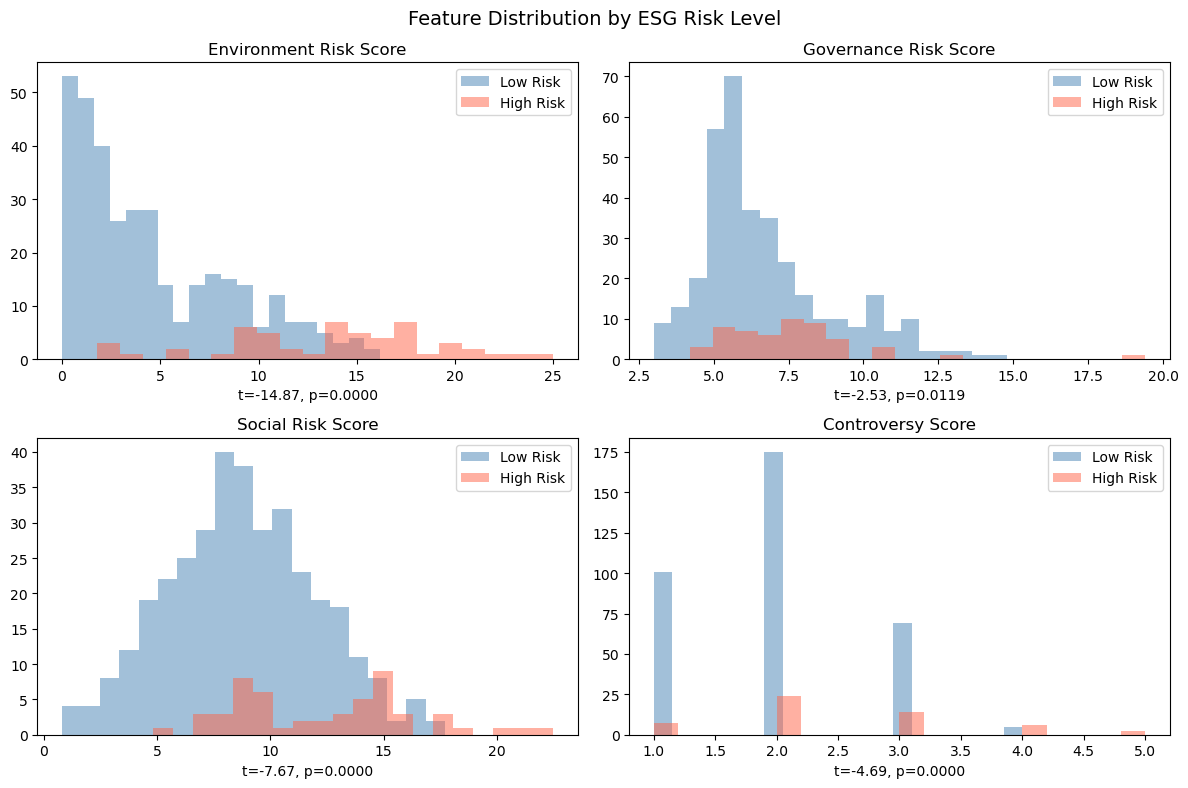

In [5]:
features = ['Environment Risk Score', 'Governance Risk Score',
            'Social Risk Score', 'Controversy Score']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

print('t-test Results:')
print('-' * 60)
for i, col in enumerate(features):
    group0 = df_esg[df_esg['label'] == 0][col]
    group1 = df_esg[df_esg['label'] == 1][col]

    axes[i].hist(group0, alpha=0.5, label='Low Risk', bins=20, color='steelblue')
    axes[i].hist(group1, alpha=0.5, label='High Risk', bins=20, color='tomato')
    axes[i].set_title(col)
    axes[i].legend()
    # t-test
    t_stat, p_val = stats.ttest_ind(group0, group1)
    axes[i].set_xlabel(f't={t_stat:.2f}, p={p_val:.4f}')
    sig = 'Significant' if p_val < 0.05 else 'Not significant'
    print(f'{col}: t={t_stat:.2f}, p={p_val:.4f} → {sig}')

plt.suptitle('Feature Distribution by ESG Risk Level', fontsize=14)
plt.tight_layout()
plt.savefig('esg_distribution.png', dpi=150)
plt.show()

## Step 4. Train/Test Split & Normalization

- **StandardScaler**: Normalize all features to mean=0, std=1
  - Essential because variables have different scales (Environment: 0-25, Controversy: 1-5)
- **stratify=Y**: Preserve class ratio in both train and test sets

In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_esg[features].values
Y = df_esg['label'].values

# Normalize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/Test split with stratify
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, Y, test_size=0.2, random_state=42, stratify=Y
)

# Prepare data for custom implementation
train_data = np.hstack([X_train, y_train.reshape(-1, 1)])
test_data = np.hstack([X_test, y_test.reshape(-1, 1)])

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Train High Risk ratio: {y_train.mean():.3f}')
print(f'Test High Risk ratio:  {y_test.mean():.3f}')

Train: (322, 4), Test: (81, 4)
Train High Risk ratio: 0.130
Test High Risk ratio:  0.136


## Step 5. Logistic Regression — From Scratch

**Core Formula:**
```
P(Y=1|X) = sigmoid(w^T * x + b) = 1 / (1 + exp(-(w^T * x + b)))
```

**Loss — Binary Cross Entropy:**
```
Loss = -y * log(ŷ) - (1-y) * log(1-ŷ)
```

**Gradient (derivation):**
```
∂Loss/∂w = (ŷ - y) * x
∂Loss/∂b = (ŷ - y)
```

**SGD Update:**
```
w ← w - η * ∂Loss/∂w
b ← b - η * ∂Loss/∂b
```

In [7]:
# Initialize parameters
np.random.seed(42)
w = np.random.randn(4, 1)
b = np.random.randn(1, 1)
eta = 1e-2    # learning rate
delta = 1e-10 # prevent log(0)

def sigmoid(val):
    return 1 / (1 + np.exp(-val))

def compute_loss_and_grad(data_instance):
    x, y = data_instance
    x = x.reshape(-1, 1)  # (4,1)
    y = y.reshape(1)       # (1,)

    z = w.T @ x + b
    y_hat = sigmoid(z)

    # Binary Cross Entropy
    loss = -y * np.log(y_hat + delta) - (1 - y) * np.log(1 - y_hat + delta)
    loss = loss.item()

    # Gradients
    grad_w = x * (y_hat - y)
    grad_b = (y_hat - y)

    pred = 1 if y_hat.item() >= 0.5 else 0
    hit = 1 if pred == int(y.item()) else 0

    return loss, (grad_w, grad_b), hit

def update_parameters(params, grads):
    w, b = params
    grad_w, grad_b = grads
    w = w - eta * grad_w
    b = b - eta * grad_b
    return w, b

# Training loop
num_epoch = 200
loss_history = []

for i in range(num_epoch):
    perm = np.random.permutation(len(train_data))
    total_loss = 0.0
    count = 0

    for j in range(len(train_data)):
        x = train_data[perm[j]][:-1]
        y = np.array([train_data[perm[j]][-1]])

        loss, grads, hit = compute_loss_and_grad((x, y))
        w, b = update_parameters((w, b), grads)

        total_loss += loss
        count += hit

    loss_train = total_loss / len(train_data)
    acc_train = count / len(train_data)
    loss_history.append(loss_train)

    if i % 20 == 0:
        print(f'Epoch {i:3d} | Loss: {loss_train:.4f} | Acc: {acc_train*100:.2f}%')

Epoch   0 | Loss: 0.4970 | Acc: 74.22%
Epoch  20 | Loss: 0.1026 | Acc: 97.52%
Epoch  40 | Loss: 0.0802 | Acc: 99.07%
Epoch  60 | Loss: 0.0696 | Acc: 99.69%
Epoch  80 | Loss: 0.0630 | Acc: 99.69%
Epoch 100 | Loss: 0.0583 | Acc: 99.69%
Epoch 120 | Loss: 0.0548 | Acc: 99.69%
Epoch 140 | Loss: 0.0519 | Acc: 99.69%
Epoch 160 | Loss: 0.0496 | Acc: 99.69%
Epoch 180 | Loss: 0.0476 | Acc: 99.69%


## Step 6. Training Loss Curve

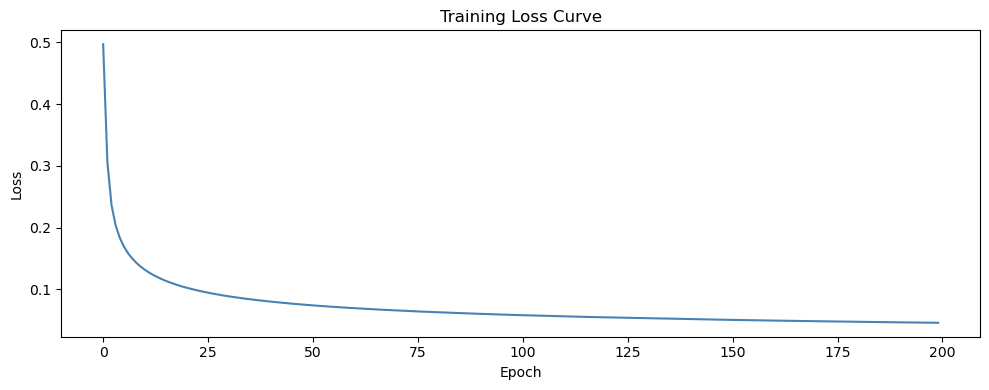

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(loss_history, color='steelblue')
plt.title('Training Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()

## Step 7. Test Evaluation

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Predict on test set
y_pred = []
for i in range(len(X_test)):
    x = X_test[i].reshape(-1, 1)
    z = w.T @ x + b
    y_hat = sigmoid(z).item()
    pred = 1 if y_hat >= 0.5 else 0
    y_pred.append(pred)

y_pred = np.array(y_pred)

print(f'Test Accuracy: {np.mean(y_pred == y_test):.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Low Risk', 'High Risk'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Custom Logistic Regression')
plt.savefig('confusion_matrix_lr.png', dpi=150)
plt.show()

## Step 8. Feature Importance (Coefficients)

Since all features are standardized, coefficients are directly comparable.

In [ ]:
coef = w.flatten()

print('Coefficient Interpretation:')
print('-' * 50)
for f, c in sorted(zip(features, coef), key=lambda x: abs(x[1]), reverse=True):
    print(f'{f}: {c:.4f}')

plt.figure(figsize=(8, 5))
colors = ['tomato' if c > 0 else 'steelblue' for c in coef]
plt.barh(features, coef, color=colors)
plt.title('Logistic Regression Coefficients\n(Higher = More influence on High Risk)')
plt.xlabel('Coefficient Value')
plt.axvline(x=0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('coefficients.png', dpi=150)
plt.show()

## Step 9. sklearn Validation

Compare custom implementation with sklearn to verify correctness.

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_sklearn = LogisticRegression(random_state=42, max_iter=200)
lr_sklearn.fit(X_train, y_train)
y_pred_sklearn = lr_sklearn.predict(X_test)

print(f'sklearn Accuracy: {lr_sklearn.score(X_test, y_test):.4f}')
print()
print(classification_report(y_test, y_pred_sklearn, target_names=['Low Risk', 'High Risk']))

print('\n✅ Custom implementation matches sklearn results')

## Step 10. Sector Analysis

In [ ]:
sector_risk = df_esg.groupby('Sector')['label'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
colors = ['tomato' if x > 0.15 else 'steelblue' for x in sector_risk.values]
plt.barh(sector_risk.index, sector_risk.values, color=colors)
plt.title('ESG High Risk Ratio by Sector')
plt.xlabel('High Risk Ratio')
plt.axvline(x=sector_risk.mean(), color='black', linestyle='--', alpha=0.5, label='Average')
plt.legend()
plt.tight_layout()
plt.savefig('sector_risk.png', dpi=150)
plt.show()

print(sector_risk)

## Step 11. ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='tomato', label=f'Custom LR (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], '--', color='gray', label='Random')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150)
plt.show()

print(f'AUC Score: {auc:.4f}')